In [1]:
!pip install pandas numpy matplotlib seaborn

## 1. Setup and Imports

In [2]:
# === Setup & Imports ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Global plot style — applied once, respected by all subsequent cells
sns.set_theme(style="whitegrid")

## 2. Loading Datasets

In [3]:
# Loading the dataset
df = pd.read_csv('karnataka_crop_dataset_V2.csv')
print(f"Shape: {df.shape}")
print(f"\nColumn dtypes:\n{df.dtypes}")
df.head()

Shape: (21960, 12)

Column dtypes:
N              float64
P              float64
K              float64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
soil_type          str
season             str
district           str
region             str
label              str
dtype: object


,N,P,K,temperature,humidity,ph,rainfall,soil_type,season,district,region,label
0,18.75,41.30,40.00,26.92,79.07,6.54,404.90,Loamy,Kharif,Hassan,Malnad,blackgram
1,117.04,29.13,103.92,24.60,51.22,6.17,132.64,Loamy,Rabi,Ramanagara,South Karnataka,mango
2,20.99,21.40,30.00,22.64,59.01,5.58,212.19,Red,Rabi,Tumakuru,South Karnataka,horsegram
3,19.89,46.24,24.29,27.99,53.42,6.51,212.80,Black,Rabi,Koppala,North Karnataka,chickpea
4,53.96,35.99,72.38,33.89,70.89,6.72,148.91,Sandy,Zaid,Chitradurga,South Karnataka,sapota


## 3. Cleaning Dataset and Verification

In [4]:
# 1. Cleaning string columns (removes accidental leading/trailing spaces)
categorical_cols = ['soil_type', 'season', 'district', 'region', 'label']
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip()
df.head()

,N,P,K,temperature,humidity,ph,rainfall,soil_type,season,district,region,label
0,18.75,41.30,40.00,26.92,79.07,6.54,404.90,Loamy,Kharif,Hassan,Malnad,blackgram
1,117.04,29.13,103.92,24.60,51.22,6.17,132.64,Loamy,Rabi,Ramanagara,South Karnataka,mango
2,20.99,21.40,30.00,22.64,59.01,5.58,212.19,Red,Rabi,Tumakuru,South Karnataka,horsegram
3,19.89,46.24,24.29,27.99,53.42,6.51,212.80,Black,Rabi,Koppala,North Karnataka,chickpea
4,53.96,35.99,72.38,33.89,70.89,6.72,148.91,Sandy,Zaid,Chitradurga,South Karnataka,sapota


In [5]:
# 2. Dataset cleaning and Verfification
# Strip accidental whitespace from all categorical columns
CATEGORICAL_COLS = ['soil_type', 'season', 'district', 'region', 'label']
for col in CATEGORICAL_COLS:
    df[col] = df[col].astype(str).str.strip()

# Verify dataset integrity
print("--- Dataset Verification ---")
print(f"Total rows     : {len(df)}")
print(f"Unique Crops   : {df['label'].nunique()}")
print(f"Unique Districts: {df['district'].nunique()}")
print(f"Unique Regions : {df['region'].nunique()}")
print(f"Unique Soil Types: {df['soil_type'].nunique()}")
print(f"\nMissing values :\n{df.isnull().sum()}")

# Summary statistics for numerical features
df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']].describe()

--- Dataset Verification ---
Total rows     : 21960
Unique Crops   : 39
Unique Districts: 31
Unique Regions : 4
Unique Soil Types: 6

Missing values :
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
soil_type      0
season         0
district       0
region         0
label          0
dtype: int64


,N,P,K,temperature,humidity,ph,rainfall
count,21960.000000,21960.000000,21960.000000,21960.000000,21960.000000,21960.000000,21960.000000
mean,87.385183,44.173338,81.801056,26.726448,64.884968,6.440398,475.729599
std,51.958329,13.352457,45.960210,3.810617,13.029716,0.505544,629.358431
min,15.000000,20.000000,15.020000,15.010000,30.010000,4.530000,53.740000
25%,53.387500,37.290000,46.280000,24.170000,55.680000,6.110000,156.357500
50%,76.980000,43.000000,68.520000,26.480000,65.020000,6.450000,283.490000
75%,113.212500,50.030000,108.040000,29.212500,75.130000,6.780000,430.142500
max,279.780000,99.950000,199.990000,37.990000,95.000000,8.000000,3678.950000


## 4. Exploratory Data Analysis (EDA)

### 4.1 Regional & Seasonal Crop Distribution

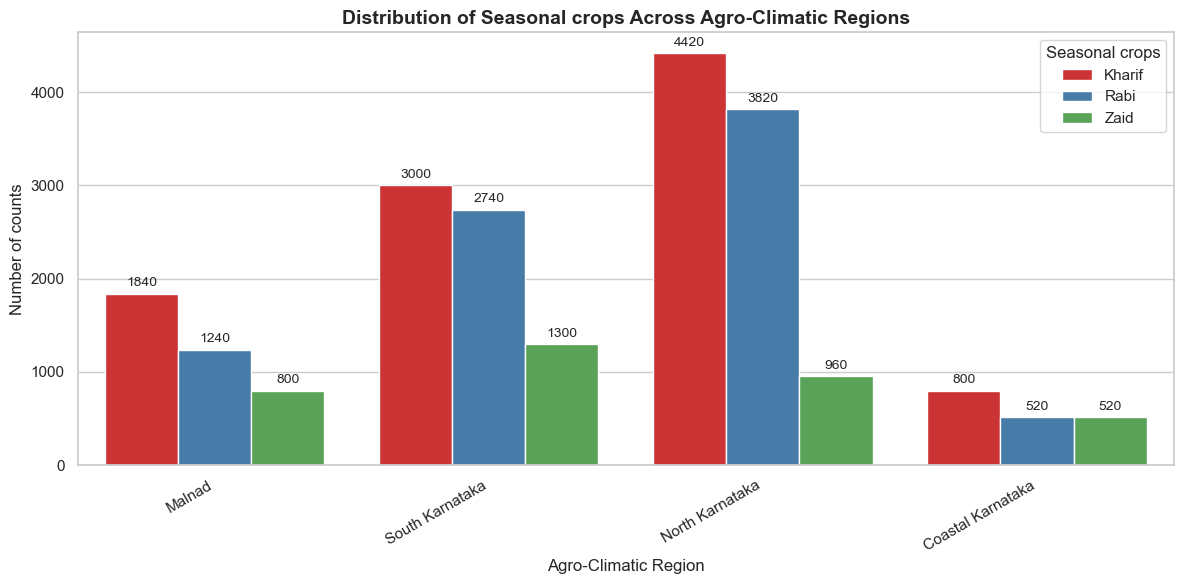

In [6]:
plt.figure(figsize=(12, 6))

# 1. Capture the plot in an 'ax' variable
ax = sns.countplot(data=df, x='region', hue='season', palette='Set1')

# 2. Add data labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding=3)

plt.title('Distribution of Seasonal crops Across Agro-Climatic Regions', fontsize=14, fontweight='bold')
plt.xlabel('Agro-Climatic Region', fontsize=12)
plt.ylabel('Number of counts', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.legend(title='Seasonal crops')

# 3. Slightly increase the layout padding so labels at the very top don't get cut off
plt.tight_layout()
plt.show()

The graph shows that most of the crop recommendations are for the Kharif crops followed by the Rabi crops and the least recommended is Zaid crops. These counts does not capture market trends, water availability, or farmer preference.

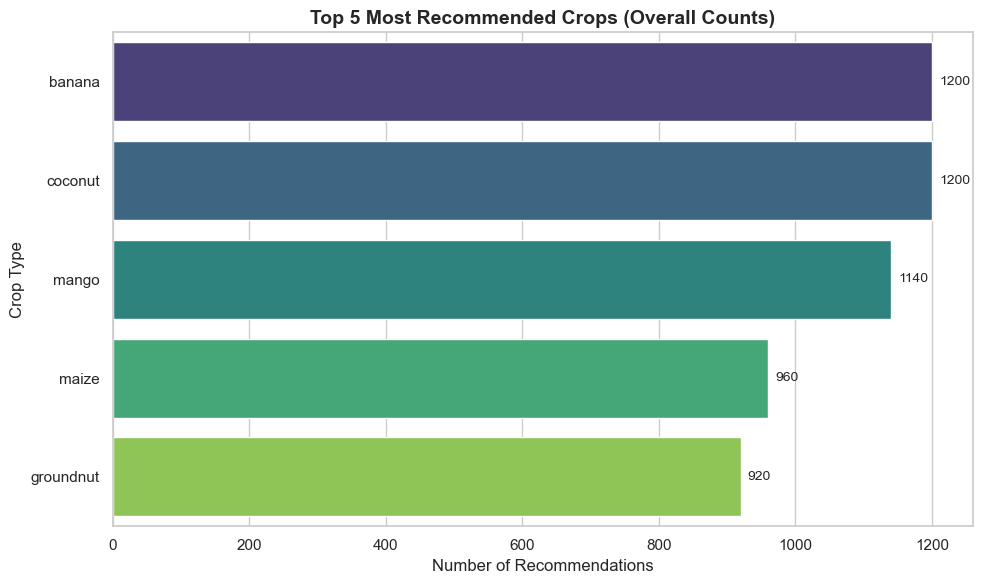

In [7]:
plt.figure(figsize=(10, 6))

# 1. Get the top 5 crop names and their total recommendation counts
top_5_crops = df['label'].value_counts().head(5)

# 2. Plot using a horizontal bar plot (x is the counts, y is the crop name)
# This makes it incredibly easy to read the names!
ax = sns.barplot(x=top_5_crops.values, y=top_5_crops.index, hue=top_5_crops.index, palette='viridis', legend=False)

# 3. Add data labels to the end of each bar
for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding=5)

# 4. Customizing labels and titles
plt.title('Top 5 Most Recommended Crops (Overall Counts)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Recommendations', fontsize=12)
plt.ylabel('Crop Type', fontsize=12)

plt.tight_layout()
plt.show()

### 4.2 Rainfall Analysis

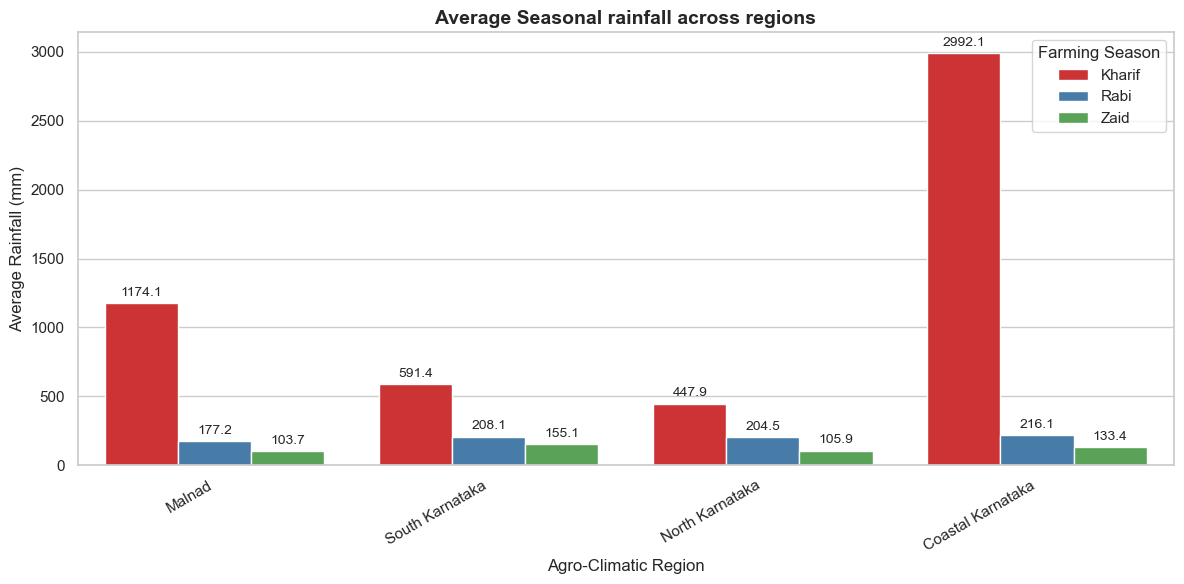

In [8]:
plt.figure(figsize=(12, 6))

# 1. Capture the plot in an 'ax' variable
ax = sns.barplot(data=df, x='region', y='rainfall', hue='season', palette='Set1', errorbar=None)

# 2. Add data labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=10, padding=3)

plt.title('Average Seasonal rainfall across regions', fontsize=14, fontweight='bold')
plt.xlabel('Agro-Climatic Region', fontsize=12)
plt.ylabel('Average Rainfall (mm)', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.legend(title='Farming Season')

# 3. Slightly increase the layout padding so labels at the very top don't get cut off
plt.tight_layout()
plt.show()

From the graph it can be seen that Coastal karnataka regions show the highest rainfall and kharif crops are recommended very highly in that region. 

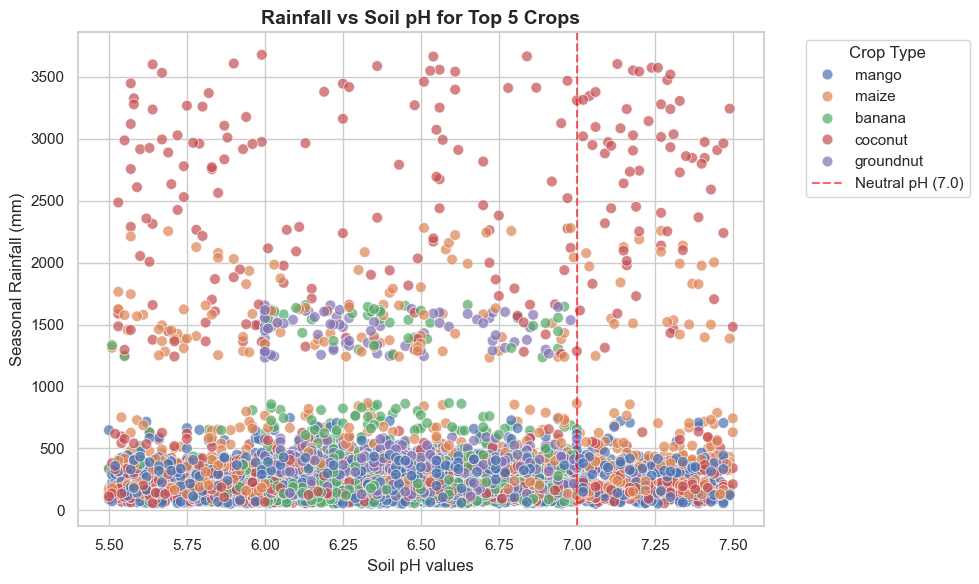

In [9]:
plt.figure(figsize=(10, 6))

# Get the top 5 most common crops in the dataset to avoid overcrowding the plot
top_5_crops = df['label'].value_counts().index[:5]
filtered_df = df[df['label'].isin(top_5_crops)]

# Scatter plot analyzing pH vs Rainfall requirements
sns.scatterplot(
    data=filtered_df, 
    x='ph', 
    y='rainfall', 
    hue='label', 
    palette='deep', 
    alpha=0.7, 
    s=60
)

# Drawing a line at pH 7 (neutral soil) for reference
plt.axvline(x=7.0, color='red', linestyle='--', alpha=0.6, label='Neutral pH (7.0)')

plt.title('Rainfall vs Soil pH for Top 5 Crops', fontsize=14, fontweight='bold')
plt.xlabel('Soil pH values', fontsize=12)
plt.ylabel('Seasonal Rainfall (mm)', fontsize=12)
plt.legend(title='Crop Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

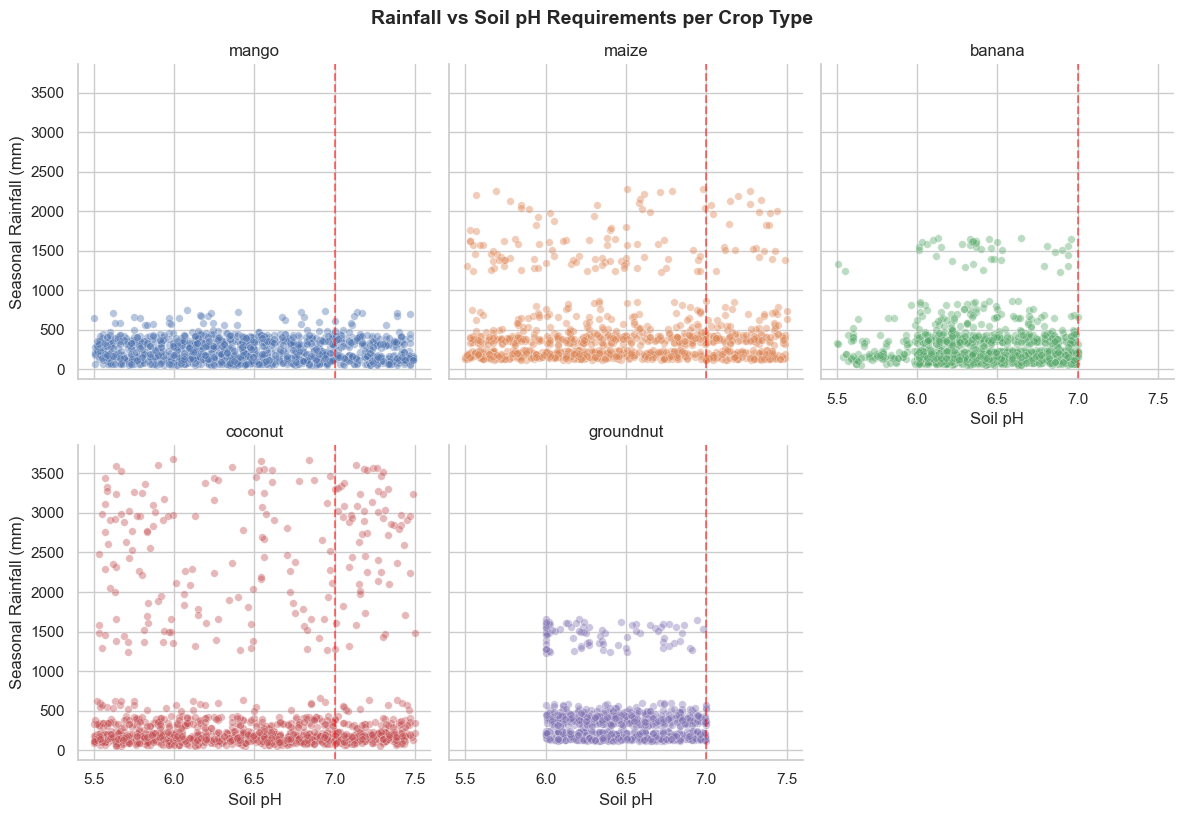

In [10]:
# 1. Filter the top 5 crops to avoid an overcrowded plot
top_5_crops = df['label'].value_counts().index[:5]
filtered_df = df[df['label'].isin(top_5_crops)]

# 2. Build the FacetGrid — one panel per crop
g = sns.FacetGrid(filtered_df, col="label", hue="label", 
                  palette="deep", col_wrap=3, height=4)

# 3. Map scatter plot onto each panel
g.map(sns.scatterplot, "ph", "rainfall", alpha=0.4, s=30)

# 4. Add reference line at neutral pH and shared axis labels
g.set_titles(template="{col_name}")
g.set_axis_labels("Soil pH", "Seasonal Rainfall (mm)")
for ax in g.axes.flat:
    ax.axvline(x=7.0, color='red', linestyle='--', alpha=0.5)

plt.suptitle("Rainfall vs Soil pH Requirements per Crop Type",
             y=1.02, fontsize=14, fontweight='bold')
plt.show()

It can be seen from the individual crop data that all crops can be grown with very little rainfall. This could be mostly owing to the large availability of water for irrigation. Or availability of water sources for irrigation nearby the fields. Outliers in all the crops (except for mango) shows the dependency of these crops with seasonal rainfall. And now coming to the pH of dependency of these crops it can be seen that groundnut is the most sensitive to pH changes. Mango is the least sensitive. And Banana requires slighlty acidic pH for growth. 

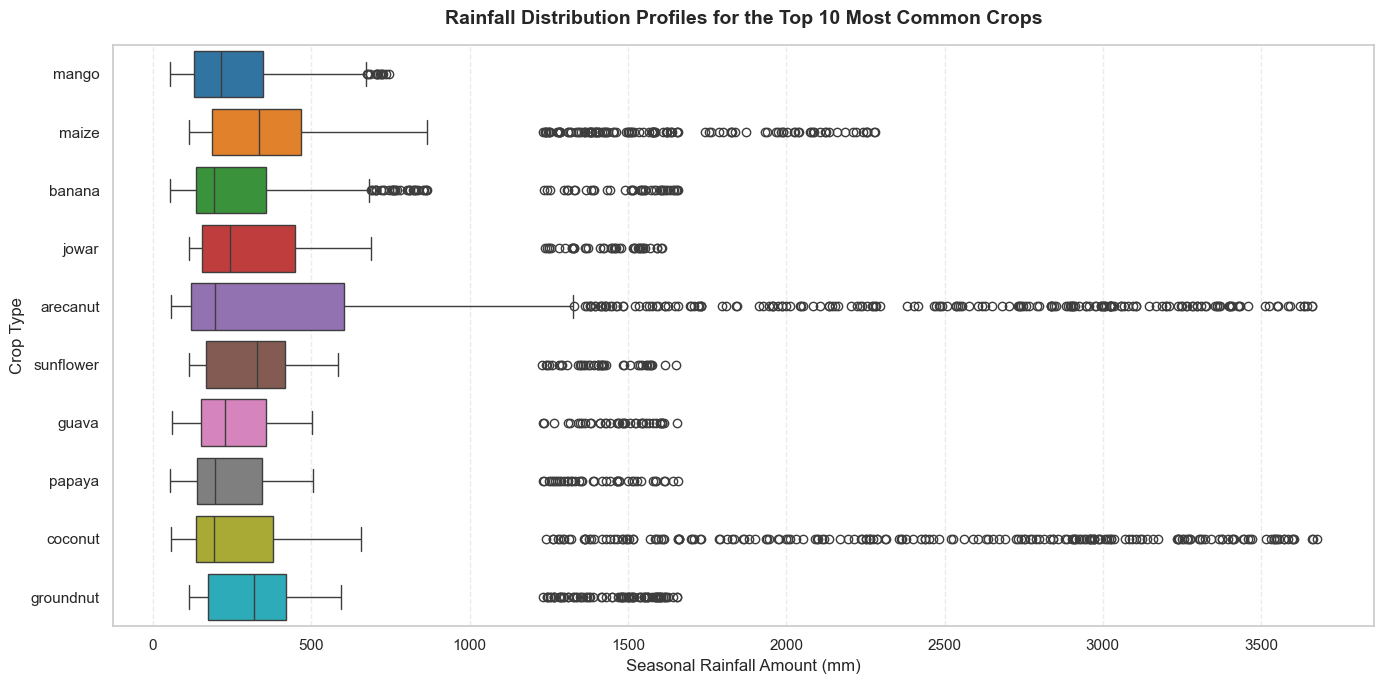

In [11]:
# 1. Identify the top 10 most frequent crops in the dataset
top_10_crop_names = df['label'].value_counts().head(10).index

# 2. Filter the main dataframe to include only these top 10 crops
filtered_df = df[df['label'].isin(top_10_crop_names)].copy()

# 3. Initialize the figure size
plt.figure(figsize=(14, 7))

# 4. Generate the horizontal boxplot
ax = sns.boxplot(
    data=filtered_df,
    x='rainfall',
    y='label',
    hue='label',
    palette='tab10',
    legend=False
)

# 5. Apply unified typography and label aesthetics
plt.title('Rainfall Distribution Profiles for the Top 10 Most Common Crops', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Seasonal Rainfall Amount (mm)', fontsize=12)
plt.ylabel('Crop Type', fontsize=12)

# Add faint vertical gridlines to make tracking percentile ranges intuitive
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### 4.3 Macro Nutrient Profiling

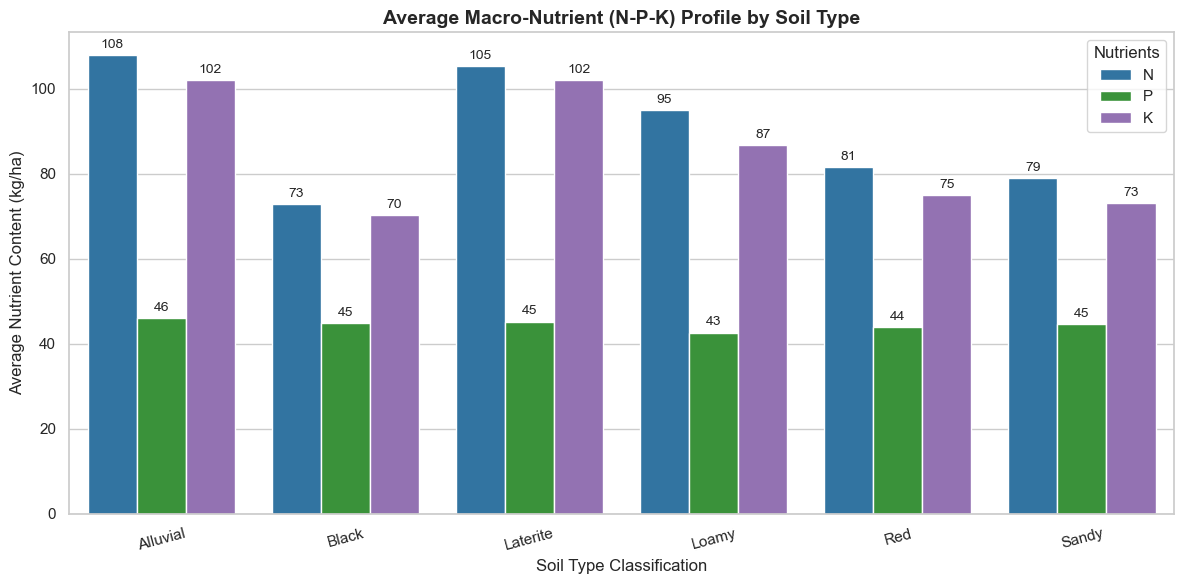

In [12]:
# 1. Group the data by soil type and calculate the mean (average) for N, P, and K
df_grouped = df.groupby('soil_type')[['N', 'P', 'K']].mean().reset_index()

# 2. Reshape the data so Seaborn can plot N, P, K side-by-side (Melting the DataFrame)
df_melted = df_grouped.melt(id_vars='soil_type', var_name='Nutrient', value_name='Average Content')

plt.figure(figsize=(12, 6))

# 3. Create a grouped bar chart
ax = sns.barplot(
    data=df_melted, 
    x='soil_type', 
    y='Average Content', 
    hue='Nutrient', 
    palette=['#1f77b4', '#2ca02c', '#9467bd'] # Blue = N, Green = P, Purple = K
)

# 4. Add clear data labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=10, padding=3)

# 5. Clean titles and axis labels
plt.title('Average Macro-Nutrient (N-P-K) Profile by Soil Type', fontsize=14, fontweight='bold')
plt.xlabel('Soil Type Classification', fontsize=12)
plt.ylabel('Average Nutrient Content (kg/ha)', fontsize=12)
plt.xticks(rotation=15)
plt.legend(title='Nutrients')

plt.tight_layout()
plt.show()

From the graph it is very clear that Black soil has the least Nutrient holding capacity. Laterite and Alluvial has the highest Nutrient holding capacity. Other soil types are at the middle average. An interesting thing we can notice here is that regardless of the soil type Phosphorous is consistently at ~45 kg/ha. 

### 4.4 Heatmaps - District and Soil types Across Crops

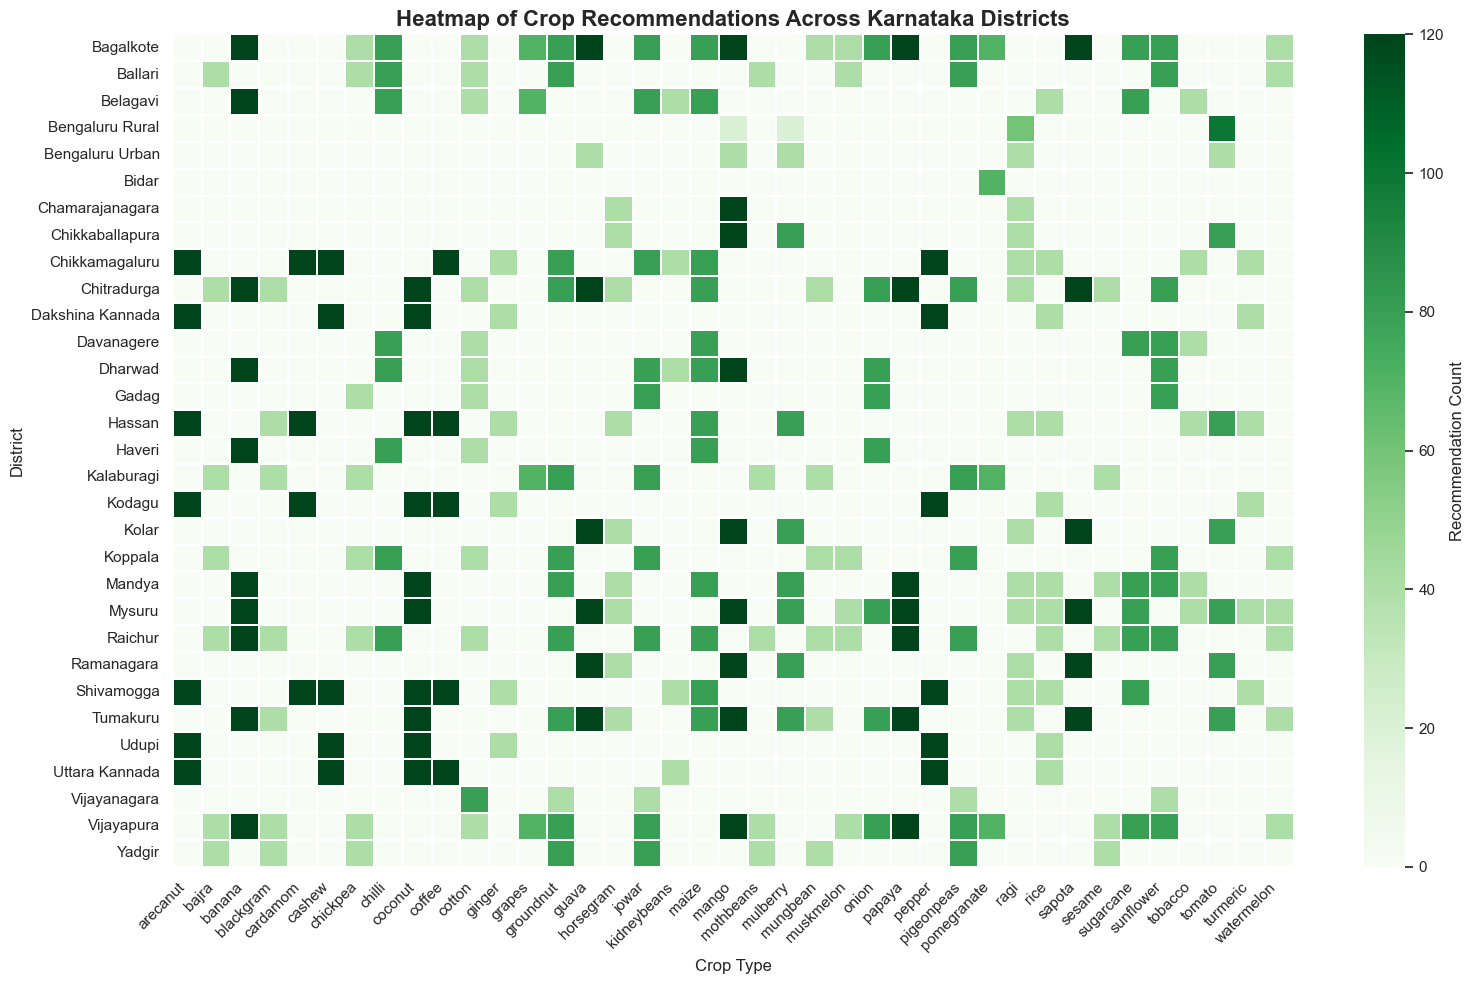

In [13]:
plt.figure(figsize=(16, 10))

# 1. Create a cross-tabulation (matrix) of District vs Crop Label
district_crop_matrix = pd.crosstab(df['district'], df['label'])

# 2. Plot the single comprehensive heatmap
sns.heatmap(
    district_crop_matrix, 
    cmap="Greens",       # Green color gradient fits agriculture
    annot=False,          # Set to True for numbers inside the cells
    linewidths=0.2, 
    cbar_kws={'label': 'Recommendation Count'}
)

plt.title('Heatmap of Crop Recommendations Across Karnataka Districts', fontsize=16, fontweight='bold')
plt.xlabel('Crop Type', fontsize=12)
plt.ylabel('District', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

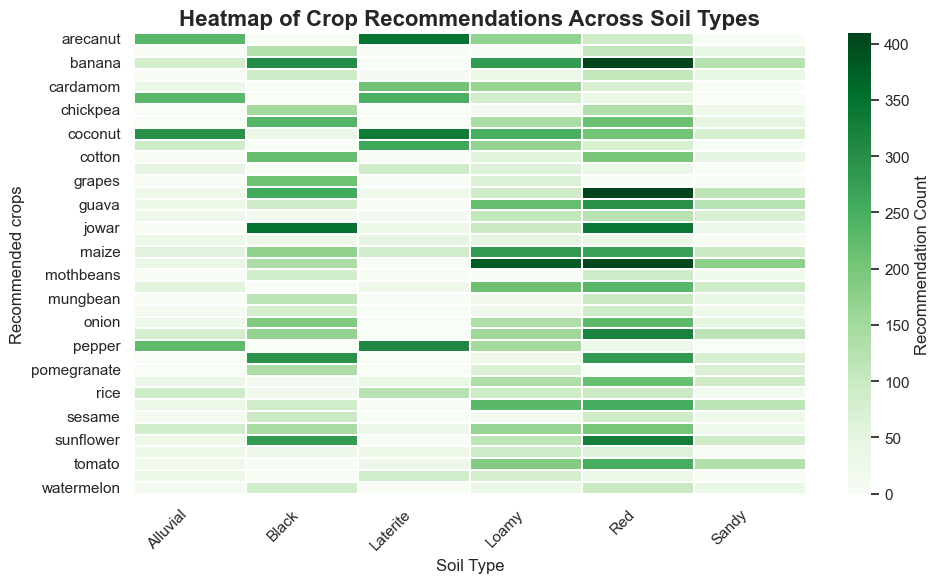

In [14]:
plt.figure(figsize=(10, 6))

# 1. Create a cross-tabulation (matrix) of District vs Crop Label
district_crop_matrix = pd.crosstab(df['label'], df['soil_type'])

# 2. Plot the single comprehensive heatmap
sns.heatmap(
    district_crop_matrix, 
    cmap="Greens",       # Green color gradient fits agriculture 
    annot=False,          # Set to True for numbers inside the cells
    linewidths=0.2, 
    cbar_kws={'label': 'Recommendation Count'}
)

plt.title('Heatmap of Crop Recommendations Across Soil Types', fontsize=16, fontweight='bold')
plt.xlabel('Soil Type', fontsize=12)
plt.ylabel('Recommended crops', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

From the heat map above it can be noticed that most of the crops that are grown are in Red, Loamy and Black soil.

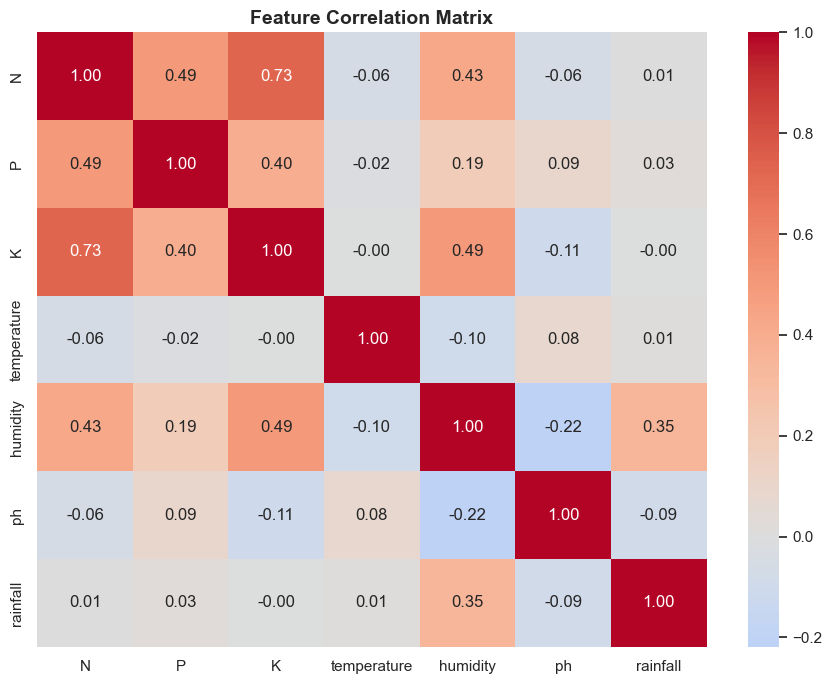

In [15]:
plt.figure(figsize=(9, 7))
# 1. Create a cross-tabulation (matrix) or correlation matrix
corr_matrix = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']].corr()

# 2. Plot the comprehensive heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.5 Nutrient Demand Rankings

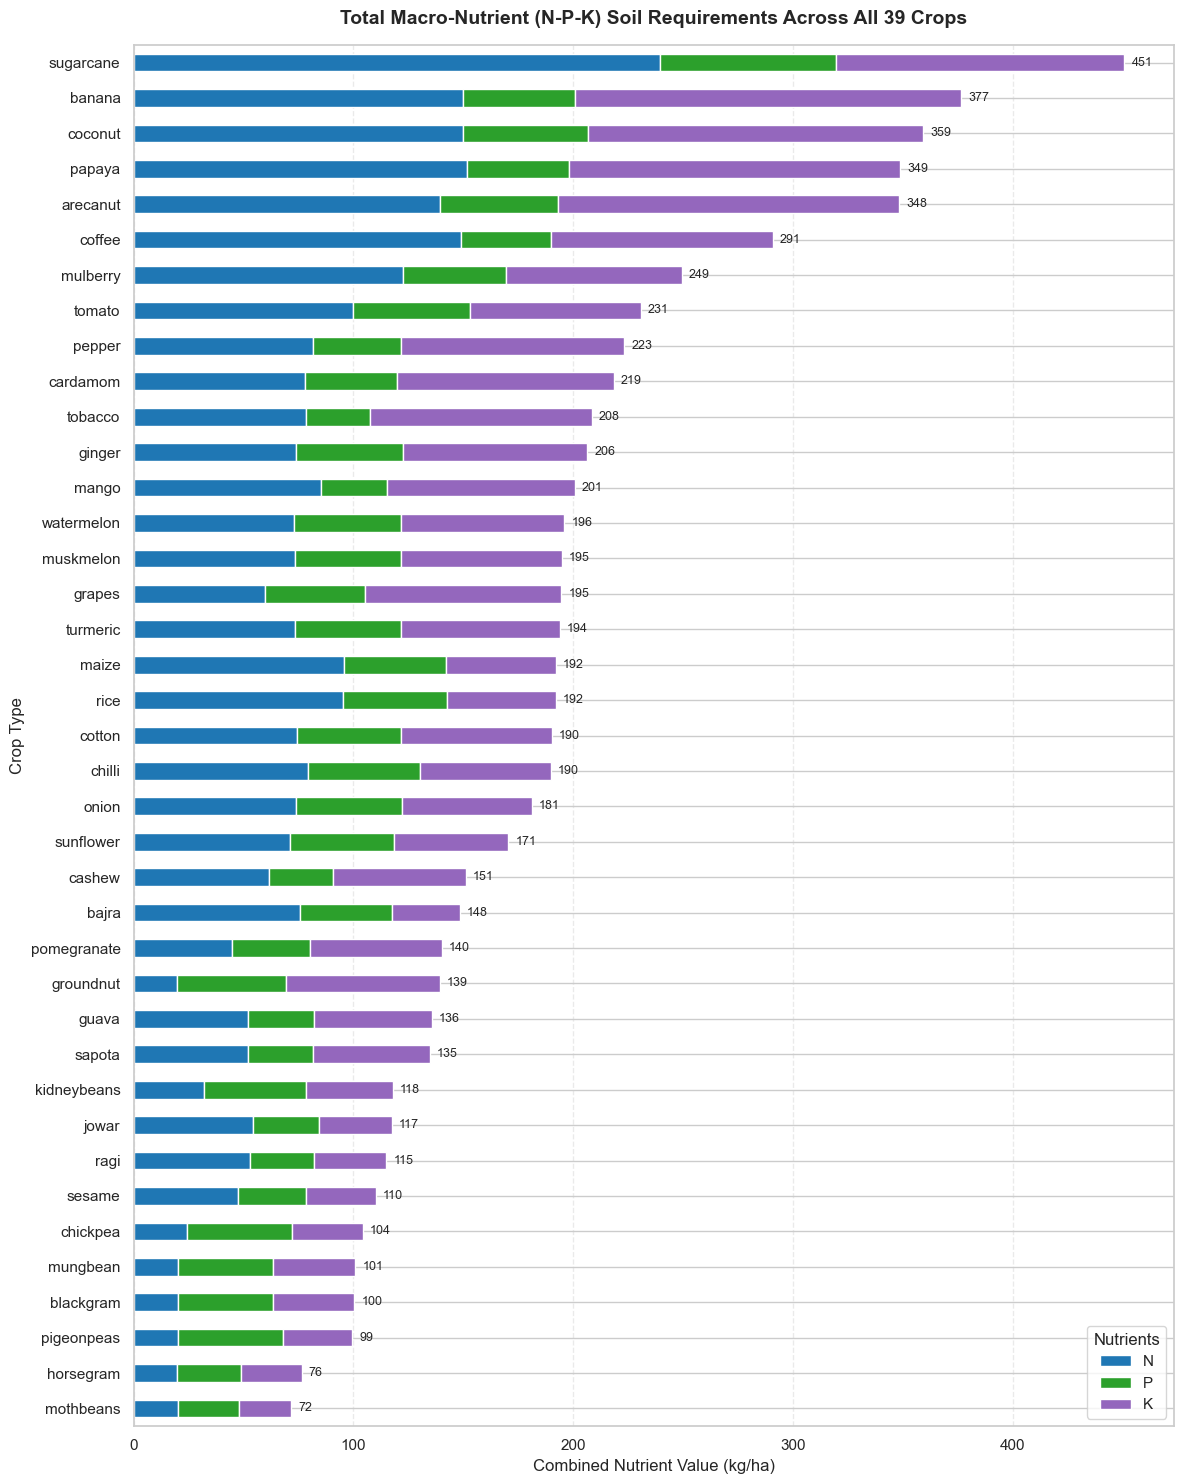

In [16]:
# 1. Group by crop label and calculate the mean nutrient levels
crop_nutrients = df.groupby('label')[['N', 'P', 'K']].mean()

# 2. Sort the crops by their total combined nutrient requirement 
crop_nutrients['Total'] = crop_nutrients['N'] + crop_nutrients['P'] + crop_nutrients['K']
crop_nutrients = crop_nutrients.sort_values(by='Total', ascending=True)

# Save the rounded totals to use as our data labels, then drop the helper column
bar_totals = crop_nutrients['Total'].round(0).astype(int)
crop_nutrients = crop_nutrients.drop(columns=['Total'])

# 3. Plot the stacked horizontal bar chart
# Setting height to 15 ensures all 39 crops have plenty of breathing room
ax = crop_nutrients.plot(
    kind='barh', 
    stacked=True, 
    figsize=(12, 15), 
    color=['#1f77b4', '#2ca02c', '#9467bd'] # Blue = N, Green = P, Purple = K
)

# 4. Add data labels showing the TOTAL nutrient content at the end of each stacked bar
ax.bar_label(ax.containers[-1], labels=bar_totals, fontsize=9, padding=5)

# 5. Clean up titles, axis text, and grids
plt.title('Total Macro-Nutrient (N-P-K) Soil Requirements Across All 39 Crops', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Combined Nutrient Value (kg/ha)', fontsize=12)
plt.ylabel('Crop Type', fontsize=12)
plt.legend(title='Nutrients', loc='lower right', fontsize=11)

# Add faint vertical gridlines to make tracking values across 39 rows easy
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

From the graph it can be seen that sugarcane as a crop absorbs the highest amounts of nutrients from the soil. Moth beans (ಮಡಕೆ ಕಾಳು/madke kalu) absorb the least amount of nutrients. 

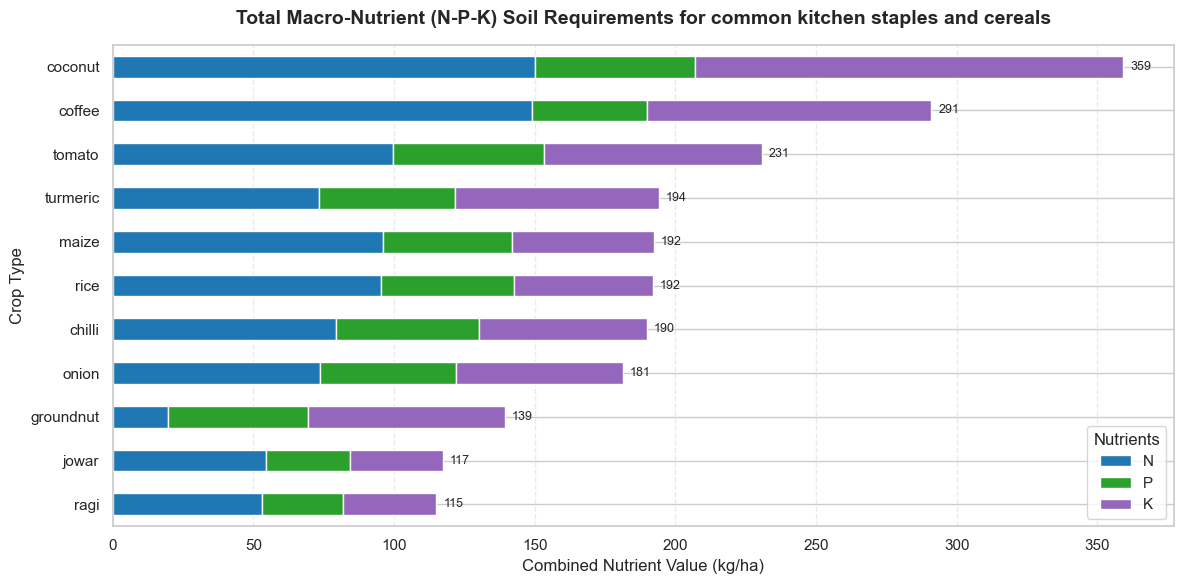

In [17]:
# 1. Group by crop label and get the mean nutrient levels
crop_nutrients = df.groupby('label')[['N', 'P', 'K']].mean().reset_index()

# 2. To keep it readable, let's filter for the top 10 most common crops or look at specific ones
# (Alternatively, you can remove this filter line to show all 39 crops, just increase figsize height!)
kitchen_crops = [
    'onion', 'tomato', 'chilli', 'coconut', 'coffee', 'turmeric', # Kitchen staples
    'rice', 'maize', 'wheat', 'ragi', 'jowar', 'groundnut'         # Common cereals
]
# Filter rows where the crop label (converted to lowercase) matches our kitchen list
filtered_nutrients = crop_nutrients[crop_nutrients['label'].str.lower().isin(kitchen_crops)]

# 3. Sort the crops by their total combined nutrient requirement 
filtered_nutrients['Total'] = filtered_nutrients['N'] + filtered_nutrients['P'] + filtered_nutrients['K']
filtered_nutrients = filtered_nutrients.sort_values(by='Total', ascending=True)
filtered_nutrients = filtered_nutrients.set_index('label')

# Save the rounded totals to use as our data labels, then drop the helper column
bar_totals = filtered_nutrients['Total'].round(0).astype(int)
plot_data = filtered_nutrients.drop(columns=['Total'])

# 4. Plot the stacked horizontal bar chart
# Setting height to 15 ensures all 39 crops have plenty of breathing room
ax = plot_data.plot(
    kind='barh', 
    stacked=True, 
    figsize=(12, 6), 
    color=['#1f77b4', '#2ca02c', '#9467bd'] # Blue = N, Green = P, Purple = K
)

# 5. Add data labels showing the TOTAL nutrient content at the end of each stacked bar
ax.bar_label(ax.containers[-1], labels=bar_totals, fontsize=9, padding=5)

# 5. Clean up titles, axis text, and grids
plt.title('Total Macro-Nutrient (N-P-K) Soil Requirements for common kitchen staples and cereals', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Combined Nutrient Value (kg/ha)', fontsize=12)
plt.ylabel('Crop Type', fontsize=12)
plt.legend(title='Nutrients', loc='lower right', fontsize=11)

# Add faint vertical gridlines to make tracking values across 39 rows easy
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

From the above graph it can be noted that the largest nutrient absorber from the soil is Coconut, and the least is Ragi. 

### 4.6 Crop Suitability Card

In [18]:
# 1. Identify the top 10 most frequent crops in the dataset
top_10_crops = df['label'].value_counts().head(10).index

# 2. Filter the dataset for only these top 10 crops
filtered_df = df[df['label'].isin(top_10_crops)].copy()

# 3. Calculate numerical averages per crop
averages_df = filtered_df.groupby('label')[['N', 'P', 'K', 'rainfall', 'ph', 'temperature']].mean()

# 4. Find the most common (mode) soil type for each crop
# We use lambda to find the value_counts().idxmax() for the soil_type column of each group
recommended_soil = filtered_df.groupby('label')['soil_type'].agg(lambda x: x.value_counts().idxmax())

# 5. Combine the averages and the recommended soil type into one clean DataFrame
suitability_card = averages_df.copy()
suitability_card['Recommended Soil'] = recommended_soil

# 6. Rename columns cleanly and round the numeric values for a polished presentation
suitability_card = suitability_card.rename(columns={
    'N': 'Avg N (kg/ha)',
    'P': 'Avg P (kg/ha)',
    'K': 'Avg K (kg/ha)',
    'rainfall': 'Avg Rainfall (mm)',
    'ph': 'Avg pH',
    'temperature': 'Avg Temp (°C)'
})

# Round numeric attributes to 1 decimal place
suitability_card = suitability_card.round(1)

# Reset index so 'Crop Type' becomes a clean column instead of the table index
suitability_card = suitability_card.reset_index().rename(columns={'label': 'Crop Type'})

# Display the clean summary table
print("--- CROP SUITABILITY CARD SUMMARY TABLE ---")
print(suitability_card.to_string(index=False))

--- CROP SUITABILITY CARD SUMMARY TABLE ---
Crop Type  Avg N (kg/ha)  Avg P (kg/ha)  Avg K (kg/ha)  Avg Rainfall (mm)  Avg pH  Avg Temp (°C) Recommended Soil
 arecanut          139.2           54.1          155.2              742.1     6.1           26.6         Laterite
   banana          149.9           51.0          175.6              285.1     6.4           27.7              Red
  coconut          150.1           56.7          152.4              588.8     6.5           26.3         Laterite
groundnut           19.6           49.8           70.0              388.6     6.5           29.0              Red
    guava           52.1           29.8           53.8              304.5     6.5           25.8              Red
    jowar           54.3           29.9           33.2              353.5     6.5           28.4            Black
    maize           95.9           46.0           50.3              476.1     6.5           24.8            Loamy
    mango           85.2           30.2     